# ANP Residual Diagnostics

Diagnostic notebook for ANP training that learns residuals on top of a frozen mean model.

This notebook mirrors the spirit of mean_only diagnostics, with direct ANP-vs-mean comparisons and exportable reports.

## 1) Set Up Environment and Imports

In [ ]:
import sys
from pathlib import Path

# Ensure repo root is on the path so anp_emulator and train_anp_emulator are importable
sys.path.insert(0, str(Path('..').resolve()))


In [4]:
from pathlib import Path
import json
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)

print('imports_ok')

imports_ok


## 2) Load Run Artifacts and Configuration

In [6]:
OUTPUT_ROOT = Path('./anp_training_runs')
RUN_DIR: Optional[Path] = Path('./anp_training_runs/anp_all_profiles_20260323_121415')  # e.g., Path('./anp_training_runs/anp_all_profiles_20260323_130000')

REPORT_DIR = Path('./anp_training_runs/diagnostic_reports')
REPORT_DIR.mkdir(parents=True, exist_ok=True)


def _safe_read_json(path: Path) -> Dict[str, Any]:
    if not path.exists():
        raise FileNotFoundError(f'Missing file: {path}')
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)


def _find_runs(prefix: str) -> List[Path]:
    runs = [p for p in OUTPUT_ROOT.glob(f'{prefix}_*') if p.is_dir()]
    runs.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return runs


def select_run(run_dir: Optional[Path], prefix: str) -> Path:
    if run_dir is not None:
        if not run_dir.exists():
            raise FileNotFoundError(f'RUN_DIR does not exist: {run_dir}')
        return run_dir
    runs = _find_runs(prefix)
    if not runs:
        raise RuntimeError(f'No {prefix}_* runs found under {OUTPUT_ROOT}')
    return runs[0]


run_dir = select_run(RUN_DIR, 'anp')
metrics_path = run_dir / 'metrics.json'
history_path = run_dir / 'history.json'
args_path = run_dir / 'args.json'

metrics = _safe_read_json(metrics_path) if metrics_path.exists() else {}
history = _safe_read_json(history_path) if history_path.exists() else []
args = _safe_read_json(args_path) if args_path.exists() else {}

history_df = pd.DataFrame(history)

print('run_dir:', run_dir)
print('metrics_exists:', metrics_path.exists())
print('history_exists:', history_path.exists())
print('args_exists:', args_path.exists())
print('history_rows:', len(history_df))
if metrics:
    print('training_stage:', metrics.get('training_stage'))
    print('target_name:', metrics.get('target_name'))
    print('best_epoch:', metrics.get('best_epoch'))
    print('mean_source:', metrics.get('mean_prior', {}).get('source'))
    print('mean_checkpoint:', metrics.get('mean_prior', {}).get('checkpoint'))

run_dir: anp_training_runs/anp_all_profiles_20260323_121415
metrics_exists: True
history_exists: True
args_exists: True
history_rows: 423
training_stage: anp_only
target_name: all_profiles
best_epoch: 303
mean_source: loaded
mean_checkpoint: /mnt/home/mlee1/ANP_tests/anp_training_runs/mean_all_profiles_20260323_115126/mean_model.pt


## 3) Reproduce Mean-Only Baseline Outputs

In [7]:
mean_prior = metrics.get('mean_prior', {}) if metrics else {}
mean_metrics = mean_prior.get('metrics', {}) if isinstance(mean_prior, dict) else {}

if not mean_metrics:
    # Fallback: load latest mean-only run if embedded mean metrics are unavailable.
    mean_run_dir = select_run(None, 'mean')
    mean_metrics_path = mean_run_dir / 'metrics.json'
    mean_root = _safe_read_json(mean_metrics_path) if mean_metrics_path.exists() else {}
    mean_metrics = mean_root.get('mean_metrics', {})
    print('Loaded fallback mean baseline from:', mean_run_dir)
else:
    print('Loaded mean baseline from ANP metrics.mean_prior.metrics')

split_rows = []
for split in ['train', 'val', 'test']:
    mm = mean_metrics.get(split, {})
    split_rows.append({
        'split': split,
        'mean_rmse_original_units': mm.get('rmse_original_units', np.nan),
        'mean_rmse_core_original_units': mm.get('rmse_core_original_units', np.nan),
        'mean_rmse_outer_original_units': mm.get('rmse_outer_original_units', np.nan),
    })

mean_split_df = pd.DataFrame(split_rows)
mean_split_df

Loaded mean baseline from ANP metrics.mean_prior.metrics


,split,mean_rmse_original_units,mean_rmse_core_original_units,mean_rmse_outer_original_units
0,train,8.179961e+06,1.828644e+07,203039.414783
1,val,8.849039e+06,1.978224e+07,218290.427316
2,test,6.569776e+06,1.468680e+07,164022.918846


## 4) Build Diagnostic Metrics per Step

In [8]:
if len(history_df) == 0:
    print('history.json missing or empty. Run this cell again after a few epochs, or after run completion.')

step_cols = [
    c for c in [
        'epoch',
        'train_loss', 'val_loss',
        'train_rmse_norm', 'val_rmse_norm',
        'train_sigma_mean', 'val_sigma_mean',
        'val_var_cal',
        'val_context_sensitivity',
        'val_rmse_original_units',
        'val_zeroshot_rmse_original_units',
        'val_weighted_orig',
    ] if c in history_df.columns
]

step_df = history_df[step_cols].copy() if step_cols else pd.DataFrame()

if len(step_df) > 0:
    if 'val_rmse_norm' in step_df.columns and 'train_rmse_norm' in step_df.columns:
        step_df['generalization_gap_rmse_norm'] = step_df['val_rmse_norm'] - step_df['train_rmse_norm']
    if 'val_loss' in step_df.columns and 'train_loss' in step_df.columns:
        step_df['generalization_gap_loss'] = step_df['val_loss'] - step_df['train_loss']

    display(step_df.tail(10))

,epoch,train_loss,val_loss,train_rmse_norm,val_rmse_norm,train_sigma_mean,val_sigma_mean,val_var_cal,val_context_sensitivity,val_rmse_original_units,val_zeroshot_rmse_original_units,val_weighted_orig,generalization_gap_rmse_norm,generalization_gap_loss
413,414,2.903886,3.048553,1.806786,1.696256,3.730772,3.755550,73.868355,NaN,984346.708333,1.054571e+06,1.617122e+06,-0.110530,0.144667
414,415,3.030155,3.242201,1.846574,1.723863,3.806095,3.712267,72.322961,0.134026,971600.270221,1.034544e+06,1.592604e+06,-0.122712,0.212046
415,416,3.072578,3.257528,1.831500,1.753876,3.795543,3.746123,73.853544,NaN,948470.908088,1.058256e+06,1.570522e+06,-0.077624,0.184950
416,417,3.215852,3.546928,1.914855,1.856269,3.852212,3.841946,69.365278,NaN,995998.731618,1.034362e+06,1.636042e+06,-0.058585,0.331076
417,418,3.004193,3.272232,1.838072,1.706773,3.775389,3.668643,75.373602,NaN,970106.851103,1.056114e+06,1.628197e+06,-0.131299,0.268038
418,419,3.000772,3.893387,1.828644,2.025294,3.784278,4.063469,73.635100,NaN,934940.166667,1.023707e+06,1.574212e+06,0.196650,0.892614
419,420,2.839552,3.466996,1.748515,1.796586,3.750418,3.838745,70.447747,0.137163,989976.069853,1.039343e+06,1.587984e+06,0.048072,0.627444
420,421,3.130089,2.856875,1.829937,1.568223,3.721480,3.485393,74.147129,NaN,966306.267157,1.005277e+06,1.639567e+06,-0.261714,-0.273214
421,422,3.104878,2.983046,1.836166,1.746461,3.772339,3.789711,71.663754,NaN,977132.469363,1.038788e+06,1.593993e+06,-0.089705,-0.121831
422,423,3.155902,3.834817,1.855375,1.945871,3.822350,3.897360,73.802730,NaN,977412.576593,1.028243e+06,1.575598e+06,0.090496,0.678914


## 5) Visualize Drift, Error, and Stability

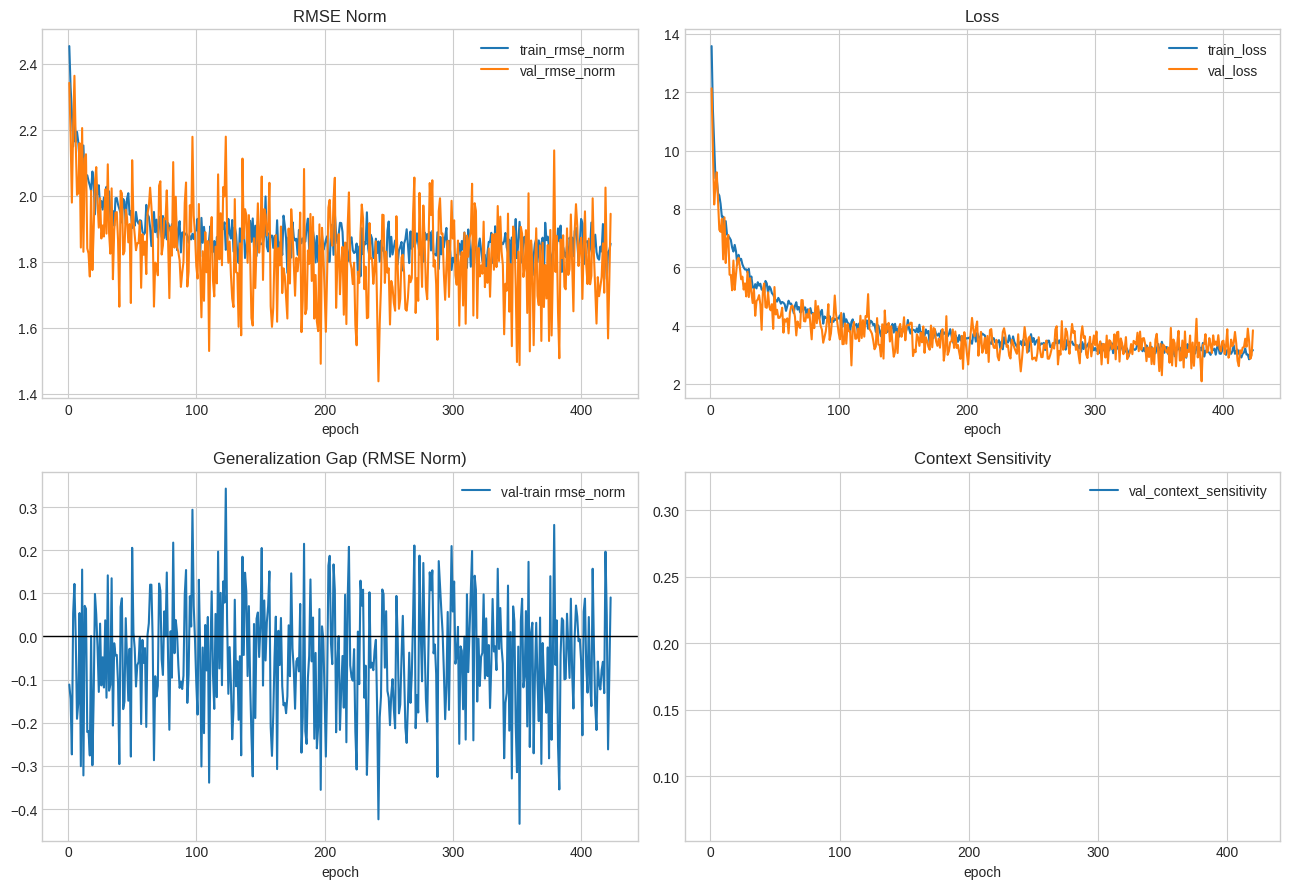

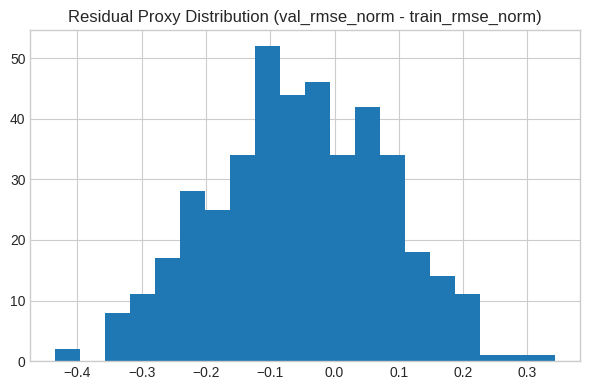

In [9]:
if len(step_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    if 'train_rmse_norm' in step_df.columns and 'val_rmse_norm' in step_df.columns:
        axes[0, 0].plot(step_df['epoch'], step_df['train_rmse_norm'], label='train_rmse_norm')
        axes[0, 0].plot(step_df['epoch'], step_df['val_rmse_norm'], label='val_rmse_norm')
        axes[0, 0].set_title('RMSE Norm')
        axes[0, 0].legend()

    if 'train_loss' in step_df.columns and 'val_loss' in step_df.columns:
        axes[0, 1].plot(step_df['epoch'], step_df['train_loss'], label='train_loss')
        axes[0, 1].plot(step_df['epoch'], step_df['val_loss'], label='val_loss')
        axes[0, 1].set_title('Loss')
        axes[0, 1].legend()

    if 'generalization_gap_rmse_norm' in step_df.columns:
        axes[1, 0].plot(step_df['epoch'], step_df['generalization_gap_rmse_norm'], label='val-train rmse_norm')
        axes[1, 0].axhline(0.0, color='k', lw=1.0)
        axes[1, 0].set_title('Generalization Gap (RMSE Norm)')
        axes[1, 0].legend()

    if 'val_context_sensitivity' in step_df.columns:
        axes[1, 1].plot(step_df['epoch'], step_df['val_context_sensitivity'], label='val_context_sensitivity')
        axes[1, 1].set_title('Context Sensitivity')
        axes[1, 1].legend()
    else:
        axes[1, 1].axis('off')

    for ax in axes.flatten():
        if ax.has_data():
            ax.set_xlabel('epoch')

    plt.tight_layout()
    plt.show()

    resid_proxy = None
    if 'val_rmse_norm' in step_df.columns and 'train_rmse_norm' in step_df.columns:
        resid_proxy = (step_df['val_rmse_norm'] - step_df['train_rmse_norm']).dropna()
    if resid_proxy is not None and len(resid_proxy) > 3:
        fig, ax = plt.subplots(1, 1, figsize=(6, 4))
        ax.hist(resid_proxy.values, bins=20)
        ax.set_title('Residual Proxy Distribution (val_rmse_norm - train_rmse_norm)')
        plt.tight_layout()
        plt.show()

## 6) Inspect Edge Cases and Failure Windows

Worst epochs by val_weighted_orig:


,epoch,val_weighted_orig,val_loss,val_rmse_norm,val_context_sensitivity
1,2,4.861058e+07,10.019045,2.185499,NaN
9,10,4.787582e+07,6.268391,1.843623,0.100766
0,1,4.781094e+07,12.135038,2.342500,0.076143
6,7,3.723014e+07,7.283068,2.003157,NaN
3,4,3.640660e+07,8.812070,2.202813,NaN
10,11,3.239563e+07,7.708672,2.205640,NaN
4,5,3.120624e+07,9.255544,2.364007,0.064384
5,6,2.497370e+07,8.281577,2.163562,NaN
8,9,2.433400e+07,7.655812,2.160024,NaN
7,8,2.287247e+07,7.213496,2.008391,NaN


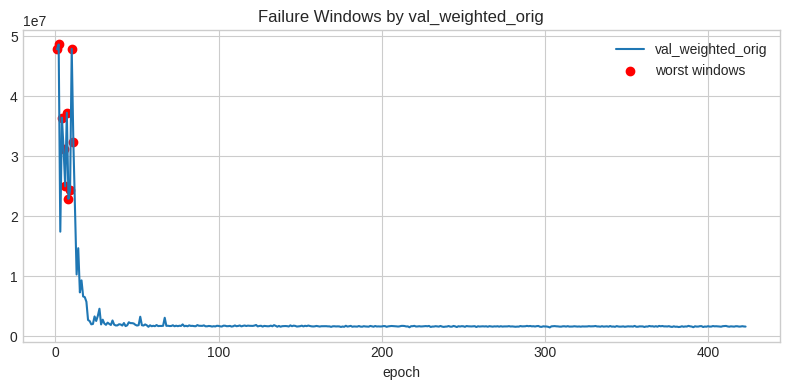

In [10]:
if len(step_df) > 0:
    rank_col = 'val_weighted_orig' if 'val_weighted_orig' in step_df.columns else (
        'val_rmse_original_units' if 'val_rmse_original_units' in step_df.columns else (
            'val_rmse_norm' if 'val_rmse_norm' in step_df.columns else None
        )
    )

    if rank_col is None:
        print('No ranking column available for edge-case selection.')
    else:
        worst_k = min(10, len(step_df))
        worst_df = step_df.sort_values(rank_col, ascending=False).head(worst_k).copy()
        print(f'Worst epochs by {rank_col}:')
        display(worst_df[['epoch', rank_col] + [c for c in ['val_loss', 'val_rmse_norm', 'val_context_sensitivity'] if c in worst_df.columns]])

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(step_df['epoch'], step_df[rank_col], label=rank_col)
        ax.scatter(worst_df['epoch'], worst_df[rank_col], color='red', label='worst windows')
        ax.set_title(f'Failure Windows by {rank_col}')
        ax.set_xlabel('epoch')
        ax.legend()
        plt.tight_layout()
        plt.show()

## 7) Compare Current Run vs Mean-Only Diagnostic

,metric,anp,mean_only,delta_run_minus_mean
0,rmse_original_units,1.053685e+06,6.569776e+06,-5.516091e+06
1,rmse_core_original_units,2.551944e+06,1.468680e+07,-1.213486e+07
2,rmse_outer_original_units,1.079515e+05,1.640229e+05,-5.607146e+04
3,zeroshot_rmse_original_units,1.054746e+06,NaN,NaN


,target,anp_rmse,mean_rmse,delta_run_minus_mean,gain_pct_vs_mean
0,stellar_density,4.887439e+05,1.726550e+07,-1.677676e+07,9.716925e+01
1,DM_density,1.035751e+06,2.009001e+06,-9.732497e+05,4.844446e+01
2,potential,1.245441e+04,1.315331e+04,-6.989001e+02,5.313494e+00
3,temperature,2.141160e-01,3.557370e-01,-1.416210e-01,3.981059e+01
4,metallicity,2.020975e-01,2.791715e-01,-7.707403e-02,2.760813e+01
5,gas_density,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
6,pressure,2.150415e-22,1.673780e-22,4.766350e-23,-4.766350e-09


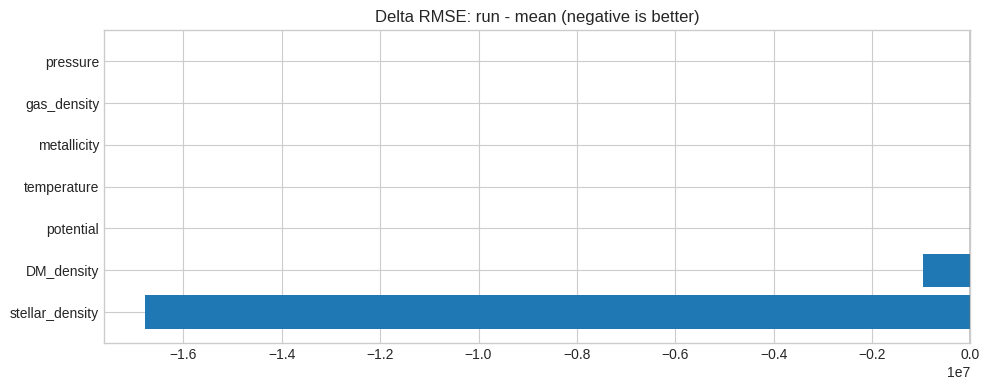

In [11]:
if not metrics:
    print('metrics.json not available yet.')
    delta_df = pd.DataFrame()
else:
    anp_test = metrics.get('test', {})
    anp_zero = metrics.get('test_zeroshot', {})

    mean_test = mean_metrics.get('test', {}) if isinstance(mean_metrics, dict) else {}

    overall = pd.DataFrame([
        {
            'metric': 'rmse_original_units',
            'anp': anp_test.get('rmse_original_units', np.nan),
            'mean_only': mean_test.get('rmse_original_units', np.nan),
        },
        {
            'metric': 'rmse_core_original_units',
            'anp': anp_test.get('rmse_core_original_units', np.nan),
            'mean_only': mean_test.get('rmse_core_original_units', np.nan),
        },
        {
            'metric': 'rmse_outer_original_units',
            'anp': anp_test.get('rmse_outer_original_units', np.nan),
            'mean_only': mean_test.get('rmse_outer_original_units', np.nan),
        },
        {
            'metric': 'zeroshot_rmse_original_units',
            'anp': anp_zero.get('rmse_original_units', np.nan),
            'mean_only': np.nan,
        },
    ])
    overall['delta_run_minus_mean'] = overall['anp'] - overall['mean_only']
    display(overall)

    anp_pt = anp_test.get('per_target', {})
    mean_pt = mean_test.get('per_target', {}) if isinstance(mean_test, dict) else {}

    rows = []
    for k in sorted(set(anp_pt.keys()) | set(mean_pt.keys())):
        m_rmse = float(mean_pt.get(k, {}).get('rmse_original_units', np.nan))
        a_rmse = float(anp_pt.get(k, {}).get('rmse_original_units', np.nan))
        rows.append({
            'target': k,
            'anp_rmse': a_rmse,
            'mean_rmse': m_rmse,
            'delta_run_minus_mean': a_rmse - m_rmse,
            'gain_pct_vs_mean': 100.0 * (m_rmse - a_rmse) / max(1e-12, m_rmse),
        })

    delta_df = pd.DataFrame(rows)
    if len(delta_df) > 0:
        display(delta_df.sort_values('delta_run_minus_mean').reset_index(drop=True))

        fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(delta_df))))
        d = delta_df.sort_values('delta_run_minus_mean', ascending=True)
        ax.barh(d['target'], d['delta_run_minus_mean'])
        ax.axvline(0.0, color='k', lw=1.0)
        ax.set_title('Delta RMSE: run - mean (negative is better)')
        plt.tight_layout()
        plt.show()

## 8) Export Diagnostic Report and Key Plots

In [12]:
report_name = f"diag_{run_dir.name}"
report_path = REPORT_DIR / report_name
report_path.mkdir(parents=True, exist_ok=True)

if len(step_df) > 0:
    step_df.to_csv(report_path / 'step_metrics.csv', index=False)
if len(mean_split_df) > 0:
    mean_split_df.to_csv(report_path / 'mean_split_metrics.csv', index=False)
if 'delta_df' in globals() and isinstance(delta_df, pd.DataFrame) and len(delta_df) > 0:
    delta_df.to_csv(report_path / 'delta_vs_mean_per_target.csv', index=False)

summary_payload = {
    'run_dir': str(run_dir),
    'training_stage': metrics.get('training_stage') if metrics else None,
    'best_epoch': metrics.get('best_epoch') if metrics else None,
    'best_score': metrics.get('best_score') if metrics else None,
    'test_rmse_original_units': (metrics.get('test', {}) or {}).get('rmse_original_units') if metrics else None,
    'mean_test_rmse_original_units': (mean_metrics.get('test', {}) or {}).get('rmse_original_units') if isinstance(mean_metrics, dict) else None,
}

with (report_path / 'summary.json').open('w', encoding='utf-8') as f:
    json.dump(summary_payload, f, indent=2)

print('Exported report to:', report_path)
print('Files:', sorted([p.name for p in report_path.glob('*')]))

Exported report to: anp_training_runs/diagnostic_reports/diag_anp_all_profiles_20260323_121415
Files: ['delta_vs_mean_per_target.csv', 'mean_split_metrics.csv', 'step_metrics.csv', 'summary.json']


## Quick Readout

Use these rules of thumb:

1. If $\Delta = \mathrm{RMSE}_{\mathrm{run}} - \mathrm{RMSE}_{\mathrm{mean}} < 0$, ANP is beating the mean baseline.
2. If context sensitivity rises above near-zero and stays stable, ANP is using context rather than collapsing.
3. If few-shot RMSE improves with context count, residual conditioning is working.
4. If worst-window spikes are transient (not monotonic drift), training is likely stable.